# 02 · Visualización de Datos — TechStore

**Parte 2: Visualización de Datos en BI**
Inteligencia de Negocios — Laboratorio de Visualización con Python + Power BI

## Objetivo

Construir un conjunto de visualizaciones analíticas sobre el datamart de ventas de TechStore
(modelo estrella `fact_ventas` + dimensiones), con el fin de:

1. Explorar la **evolución temporal** de las ventas.
2. Identificar la **concentración del catálogo** (análisis de Pareto).
3. Comparar la **distribución de ventas por categoría** de producto.
4. Detectar patrones de **estacionalidad** cruzando mes y categoría (mapa de calor).
5. Complementar el análisis con una visualización **interactiva** (Plotly).

Cada gráfico se acompaña de una celda de narrativa (Markdown) que interpreta el resultado
y sugiere una posible decisión de negocio. Al final del notebook se presenta un resumen
consolidado de hallazgos accionables.

## Estructura de carpetas esperada

```
proyecto/
├── data/
│   └── processed/          <- CSVs del datamart (fact_ventas, dim_*)
├── notebook/
│   └── 02_visualizacion.ipynb   <- este archivo
└── informe/
    └── img/                <- figuras exportadas (.png / .html)
```

> Este notebook asume que se ejecuta desde la carpeta `notebook/`, por lo que las rutas
> relativas usan `../data/processed` y `../informe/img`.


## 1. Configuración del entorno

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

# Estilo visual consistente para todas las figuras estáticas
sns.set_theme(style="whitegrid", context="notebook")
PALETA = sns.color_palette("mako", 10)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Rutas del proyecto (relativas a la carpeta notebook/)
DATA_DIR = Path("../data/processed")
IMG_DIR = Path("../informe/img")
IMG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"No se encontró la carpeta de datos: {DATA_DIR.resolve()}"
print("Carpeta de datos     :", DATA_DIR.resolve())
print("Carpeta de figuras   :", IMG_DIR.resolve())


Carpeta de datos     : C:\Users\renzo\Downloads\proyecto-bi-techstore\data\processed
Carpeta de figuras   : C:\Users\renzo\Downloads\proyecto-bi-techstore\informe\img


## 2. Carga de datos

Se cargan la tabla de hechos `fact_ventas` y las dimensiones `dim_producto`, `dim_tienda`,
`dim_promocion`, `dim_tiempo` y `dim_cliente`, tal como fueron dejadas por el proceso ETL
(carpeta `data/processed`).

In [3]:
fact_ventas = pd.read_csv(DATA_DIR / "fact_ventas.csv", parse_dates=["fecha"])
dim_producto = pd.read_csv(DATA_DIR / "dim_producto.csv")
dim_tienda = pd.read_csv(DATA_DIR / "dim_tienda.csv")
dim_promocion = pd.read_csv(DATA_DIR / "dim_promocion.csv", parse_dates=["fecha_inicio", "fecha_fin"])
dim_tiempo = pd.read_csv(DATA_DIR / "dim_tiempo.csv", parse_dates=["fecha"])
dim_cliente = pd.read_csv(DATA_DIR / "dim_cliente.csv", parse_dates=["fecha_nacimiento", "fecha_alta"])

print(f"fact_ventas   : {fact_ventas.shape[0]:,} filas x {fact_ventas.shape[1]} columnas")
print(f"dim_producto  : {dim_producto.shape[0]:,} filas")
print(f"dim_tienda    : {dim_tienda.shape[0]:,} filas")
print(f"dim_promocion : {dim_promocion.shape[0]:,} filas")
print(f"dim_tiempo    : {dim_tiempo.shape[0]:,} filas")
print(f"dim_cliente   : {dim_cliente.shape[0]:,} filas")

fact_ventas.head()


fact_ventas   : 59,700 filas x 12 columnas
dim_producto  : 500 filas
dim_tienda    : 15 filas
dim_promocion : 41 filas
dim_tiempo    : 730 filas
dim_cliente   : 5,000 filas


,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo_total,margen
0,17504,2025-10-12,2235,253,13,38,3,143.04,20.00,343.30,274.02,69.28
1,46116,2025-12-25,4031,426,4,0,1,346.19,0.00,346.19,242.97,103.22
2,59784,2024-08-27,4363,194,8,0,2,475.39,0.00,950.78,553.02,397.76
3,11462,2024-12-19,2934,426,10,5,2,313.40,30.00,438.76,485.94,-47.18
4,50030,2024-05-11,1351,46,3,0,1,536.19,0.00,536.19,366.20,169.99


## 3. Construcción del dataset analítico (modelo enriquecido)

Se renombran las columnas ambiguas de cada dimensión (todas tienen un campo `nombre`) y se
unen con `fact_ventas` para obtener una tabla plana lista para graficar.

In [4]:
# Renombrar columnas que se repiten entre dimensiones antes de unir
prod = dim_producto.rename(columns={"nombre": "producto", "costo": "costo_producto"})
tienda = dim_tienda.rename(columns={"nombre": "tienda"})
promo = dim_promocion.rename(columns={"nombre": "promocion", "tipo": "tipo_promocion"})
cliente = dim_cliente.rename(columns={"nombre": "cliente"})

df = (
    fact_ventas
    .merge(prod, on="id_producto", how="left")
    .merge(tienda, on="id_tienda", how="left")
    .merge(promo, on="id_promocion", how="left", suffixes=("", "_promo"))
    .merge(dim_tiempo, on="fecha", how="left")
    .merge(cliente[["id_cliente", "segmento_programa"]], on="id_cliente", how="left")
)

# Nombres de mes en español, ordenados (evita depender del locale del sistema operativo)
MESES_ES = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
    7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre",
}
df["mes_nombre"] = df["mes"].map(MESES_ES)
df["mes_nombre"] = pd.Categorical(df["mes_nombre"], categories=list(MESES_ES.values()), ordered=True)
df["periodo"] = df["fecha"].dt.to_period("M")

print(f"Dataset enriquecido: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df[["fecha", "producto", "categoria", "tienda", "canal", "region", "importe", "margen"]].head()


Dataset enriquecido: 59,700 filas x 36 columnas


,fecha,producto,categoria,tienda,canal,region,importe,margen
0,2025-10-12,Anker Cables LC-9854,Accesorios,Techstore Online Perú,Online,Lima,343.30,69.28
1,2025-12-25,Targus Fundas MO-6208,Accesorios,Techstore Mega Plaza,Fisico,Lima,346.19,103.22
2,2024-08-27,Razer Teclados IQ-2013,Perifericos,Techstore Callao,Fisico,Callao,950.78,397.76
3,2024-12-19,Targus Fundas MO-6208,Accesorios,Techstore Trujillo Mall Aventura,Fisico,La Libertad,438.76,-47.18
4,2024-05-11,Redragon Mouse ZE-2149,Perifericos,Techstore Jockey Plaza,Fisico,Lima,536.19,169.99


### 3.1 Verificación rápida de calidad de datos

Un vistazo rápido antes de graficar: rango de fechas, nulos remanentes y proporción de
líneas de venta con margen negativo (relevante para el hallazgo sobre descuentos).

In [5]:
print("Rango de fechas       :", df["fecha"].min().date(), "→", df["fecha"].max().date())
print("Nulos por columna clave:")
print(df[["categoria", "region", "canal", "importe", "margen"]].isna().sum())

margen_neg = (df["margen"] < 0).sum()
print(f"\nLíneas con margen negativo: {margen_neg:,} de {len(df):,} ({margen_neg/len(df)*100:.1f}%)")


Rango de fechas       : 2024-01-01 → 2025-12-30
Nulos por columna clave:
categoria    0
region       0
canal        0
importe      0
margen       0
dtype: int64

Líneas con margen negativo: 6,615 de 59,700 (11.1%)


## 4. Visualización 1 — Evolución temporal de ventas

Se compara la evolución **mes a mes** de las ventas (`importe`) entre 2024 y 2025 para
identificar tendencia y estacionalidad.

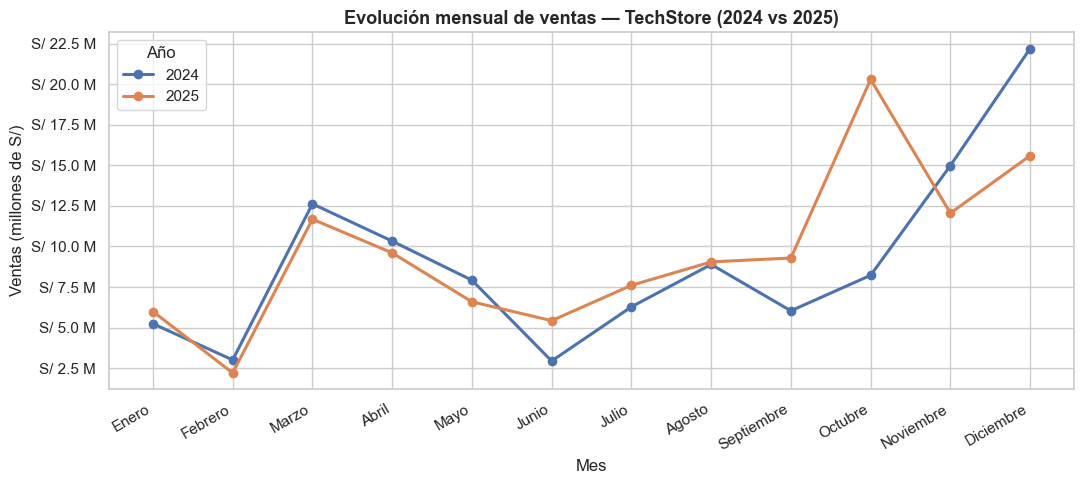

In [6]:
ventas_mes_anio = (
    df.groupby(["anio", "mes", "mes_nombre"], observed=True)["importe"]
    .sum()
    .reset_index()
    .sort_values(["anio", "mes"])
)

fig, ax = plt.subplots(figsize=(11, 5))

for anio, color in zip(sorted(ventas_mes_anio["anio"].unique()), ["#4C72B0", "#DD8452"]):
    sub = ventas_mes_anio[ventas_mes_anio["anio"] == anio]
    ax.plot(sub["mes_nombre"], sub["importe"] / 1_000_000, marker="o", label=str(anio), color=color, linewidth=2.2)

ax.set_title("Evolución mensual de ventas — TechStore (2024 vs 2025)")
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas (millones de S/)")
ax.legend(title="Año")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("S/ %.1f M"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig(IMG_DIR / "01_evolucion_mensual_ventas.png", dpi=120)
plt.show()


**Lectura del gráfico.** Ambos años muestran un patrón similar: caídas en febrero y junio,
y picos marcados en marzo/abril y, sobre todo, en noviembre–diciembre (campañas Cyber y
temporada navideña). El mes de octubre 2025 también destaca por encima de su equivalente
2024, lo que sugiere una campaña puntual o una promoción agresiva ese mes.

**Insight de negocio.** La demanda no es uniforme: hay al menos dos "temporadas altas"
(marzo–abril y noviembre–diciembre) y dos "valles" (febrero y junio). Esto debería
traducirse en una planificación de inventario y dotación de personal diferenciada por
mes, en vez de una asignación constante durante el año.

## 5. Visualización 2 — Análisis de Pareto de productos (regla 80/20)

Se evalúa cuántos productos concentran el 80% de los ingresos totales, y se grafican los
20 productos con mayores ventas junto con su curva de porcentaje acumulado.

In [ ]:
ventas_producto = (
    df.groupby("producto")["importe"].sum().sort_values(ascending=False).reset_index()
)
ventas_producto["pct"] = ventas_producto["importe"] / ventas_producto["importe"].sum() * 100
ventas_producto["pct_acum"] = ventas_producto["pct"].cumsum()

n_total = len(ventas_producto)
n_80 = (ventas_producto["pct_acum"] <= 80).sum() + 1
print(f"Productos con ventas registradas : {n_total}")
print(f"Productos que concentran el 80% de ingresos: {n_80} ({n_80/n_total*100:.1f}% del catálogo)")

top20 = ventas_producto.head(20)

fig, ax1 = plt.subplots(figsize=(12, 5.5))
bars = ax1.bar(top20["producto"], top20["importe"] / 1_000_000, color=PALETA[3])
ax1.set_ylabel("Ventas (millones de S/)")
ax1.set_xlabel("Producto")
ax1.set_title("Pareto de productos — Top 20 por ingresos")
plt.setp(ax1.get_xticklabels(), rotation=75, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(top20["producto"], top20["pct_acum"], color="#C44E52", marker="o", linewidth=2)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("% acumulado de ingresos")
ax2.set_ylim(0, 105)
ax2.text(len(top20) - 1, 82, "80%", color="gray", ha="right", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(IMG_DIR / "02_pareto_productos.png", dpi=120)
plt.show()


**Lectura del gráfico.** El primer producto de la lista concentra, por sí solo, una porción
de ingresos muy superior al resto del top 20 — una brecha inusualmente grande frente al
segundo y tercer lugar. En conjunto, solo un **porcentaje reducido del catálogo (cercano al
10%)** genera el 80% de los ingresos, un patrón de Pareto incluso más concentrado que el
clásico 80/20.

**Insight de negocio.** Conviene (1) auditar las transacciones del producto líder para
confirmar que la concentración es real y no un artefacto de carga de datos (cantidades o
precios unitarios atípicos), y (2) reforzar la gestión de reposición/stock sobre el grupo
reducido de productos "estrella", ya que una rotura de stock en ellos tendría un impacto
desproporcionado en los ingresos totales.

## 6. Visualización 3 — Distribución de ventas por categoría

Se analiza la composición de ingresos por categoría de producto (izquierda) y la
distribución del importe por transacción dentro de cada una de las principales categorías
(derecha), para entender no solo cuánto vende cada categoría sino también qué tan
homogéneo es su ticket de venta.

In [ ]:
ventas_categoria = (
    df.groupby("categoria")["importe"].sum().sort_values(ascending=False)
)
top_categorias = ventas_categoria.head(8).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel izquierdo: composición total por categoría
sns.barplot(
    x=ventas_categoria.values / 1_000_000,
    y=ventas_categoria.index,
    palette="mako",
    ax=axes[0],
)
axes[0].set_title("Ventas totales por categoría")
axes[0].set_xlabel("Ventas (millones de S/)")
axes[0].set_ylabel("Categoría")
for i, v in enumerate(ventas_categoria.values / 1_000_000):
    axes[0].text(v, i, f" S/ {v:,.1f}M", va="center", fontsize=8)

# Panel derecho: distribución del importe por transacción (top 8 categorías, escala log)
sns.boxplot(
    data=df[df["categoria"].isin(top_categorias)],
    x="importe",
    y="categoria",
    order=top_categorias,
    palette="mako",
    ax=axes[1],
    showfliers=False,
)
axes[1].set_xscale("log")
axes[1].set_title("Distribución del importe por transacción\n(top 8 categorías, escala log, sin outliers)")
axes[1].set_xlabel("Importe por transacción (S/, escala log)")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(IMG_DIR / "03_distribucion_categoria.png", dpi=120)
plt.show()


In [ ]:
margen_categoria = (
    df.groupby("categoria")
    .apply(lambda g: g["margen"].sum() / g["importe"].sum() * 100)
    .sort_values(ascending=False)
)
margen_categoria.round(1).to_frame("margen_%")


**Lectura del gráfico.** *Celulares* es, por amplio margen, la categoría con mayores
ingresos, seguida de *Computadoras* y *Sin Categoría* (productos pendientes de
clasificación en el catálogo). Sin embargo, al mirar el margen porcentual, *Celulares* y
*Laptops* están entre las categorías con **menor rentabilidad relativa**, mientras que
categorías más pequeñas en volumen como *Redes*, *Gaming* e *Impresión* tienen los
márgenes más altos. El boxplot muestra además que *Computadoras* y *Laptops* tienen tickets
por transacción más altos y dispersos que *Celulares*, que vende un volumen alto de tickets
más bajos y homogéneos.

**Insight de negocio.** Depender de la categoría de mayor volumen pero menor margen
(*Celulares*) es razonable para atraer tráfico, pero conviene reforzar el *cross-sell* de
categorías de mayor margen (accesorios, audio, gaming) en el mismo ticket de compra para
mejorar la rentabilidad global sin sacrificar volumen. También vale la pena depurar la
categoría "Sin Categoría", que representa una porción no menor de ingresos sin
clasificación clara.

## 7. Visualización 4 — Mapa de calor: estacionalidad por categoría

Se cruza el mes de venta con la categoría de producto para detectar patrones de
estacionalidad que el gráfico de línea (agregado) no muestra: ¿qué categorías impulsan los
picos de noviembre-diciembre? ¿hay categorías con estacionalidad propia?

In [ ]:
pivot_mes_cat = df.pivot_table(
    index="categoria", columns="mes_nombre", values="importe", aggfunc="sum", fill_value=0, observed=True
)
# Ordenar categorías por venta total descendente para lectura más natural
pivot_mes_cat = pivot_mes_cat.loc[ventas_categoria.index]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    pivot_mes_cat / 1000,  # en miles de soles
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Ventas (miles de S/)"},
    fmt=",.0f",
    annot=False,
    ax=ax,
)
ax.set_title("Ventas por categoría y mes (miles de S/)")
ax.set_xlabel("Mes")
ax.set_ylabel("Categoría")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")

fig.tight_layout()
fig.savefig(IMG_DIR / "04_heatmap_mes_categoria.png", dpi=120)
plt.show()


**Lectura del gráfico.** *Celulares*, *Computadoras* y *Sin Categoría* concentran su pico en
diciembre, consistente con la campaña navideña. En contraste, *Componentes* y *Tablets*
muestran su mejor mes en marzo/abril, posiblemente asociado a campaña escolar o de
regreso a clases. *Gaming* y *Monitores* alcanzan su pico en agosto, fuera de las campañas
tradicionales de fin de año, lo que sugiere una dinámica de demanda propia (quizás
lanzamientos de productos o promociones específicas del sector gamer).

**Insight de negocio.** No conviene tratar la campaña de diciembre como única prioridad
del año: categorías como *Componentes*, *Tablets* y *Gaming* tienen su propio pico fuera de
la temporada navideña y deberían tener su propio calendario de promociones y
abastecimiento.

## 8. Visualización complementaria (interactiva) — Programa de fidelización

Como complemento interactivo (Plotly), se explora si el nivel del programa de
fidelización (`segmento_programa`) realmente se traduce en un mayor ticket promedio de
compra, cruzado por canal de venta. Al ser un gráfico interactivo, permite pasar el cursor
sobre cada barra para ver el detalle exacto.

In [ ]:
resumen_segmento = (
    df.groupby(["segmento_programa", "canal"], observed=True)
    .agg(ventas_totales=("importe", "sum"), ticket_promedio=("importe", "mean"), transacciones=("id_venta", "count"))
    .reset_index()
)
orden_segmento = ["Bronce", "Plata", "Oro", "Platino"]
resumen_segmento["segmento_programa"] = pd.Categorical(
    resumen_segmento["segmento_programa"], categories=orden_segmento, ordered=True
)
resumen_segmento = resumen_segmento.sort_values("segmento_programa")

fig_px = px.bar(
    resumen_segmento,
    x="segmento_programa",
    y="ticket_promedio",
    color="canal",
    barmode="group",
    text_auto=".2s",
    labels={
        "segmento_programa": "Nivel de fidelización",
        "ticket_promedio": "Ticket promedio (S/)",
        "canal": "Canal de venta",
    },
    title="Ticket promedio por nivel de fidelización y canal de venta",
    color_discrete_sequence=["#4C72B0", "#DD8452"],
)
fig_px.update_layout(template="plotly_white", legend_title_text="Canal")
fig_px.write_html(IMG_DIR / "05_fidelizacion_canal.html")
fig_px.show()


**Lectura del gráfico.** El ticket promedio **no crece de forma consistente** con el nivel de
fidelización: el segmento *Platino* no exhibe el ticket más alto, y en algunos canales queda
incluso por debajo de *Bronce* o *Plata*. Esto indica que el programa de fidelización
probablemente está premiando la **frecuencia de compra** (o antigüedad) más que el
**valor** de cada compra.

**Insight de negocio.** Vale la pena revisar los criterios de ascenso de nivel del programa
de fidelización: si el objetivo del negocio es incrementar el ticket promedio (no solo la
frecuencia), los beneficios y criterios de "Oro"/"Platino" deberían alinearse mejor con el
valor de compra, no únicamente con la cantidad de transacciones.

## 9. Resumen de hallazgos accionables

| # | Hallazgo | Recomendación de negocio |
|---|----------|---------------------------|
| 1 | Estacionalidad clara con picos en **marzo–abril** y, sobre todo, **noviembre–diciembre**; valles en febrero y junio. | Planificar inventario y personal por temporada en vez de usar una asignación constante todo el año. |
| 2 | Un grupo reducido de productos (~10% del catálogo) concentra el **80% de los ingresos** (Pareto). | Priorizar la gestión de stock y reposición sobre ese grupo "estrella"; evaluar descontinuar productos de cola larga sin rotación. |
| 3 | Un solo producto concentra una porción desproporcionada de los ingresos, con cantidades y precios unitarios atípicos en algunas transacciones. | Auditar esas transacciones (¿ventas mayoristas legítimas o error de carga?) y diversificar el mix de celulares para reducir el riesgo de depender de un solo SKU. |
| 4 | *Celulares* domina en ingresos pero tiene **menor margen relativo** que categorías más pequeñas como Redes, Gaming o Impresión. | Impulsar cross-sell de accesorios/audio (mayor margen) junto con la venta de celulares para mejorar la rentabilidad sin perder volumen. |
| 5 | Cerca de un 11% de las líneas de venta presentan **margen negativo**, asociado a descuentos altos. | Establecer un límite máximo de descuento o revisar el diseño de promociones tipo "Liquidación" que estén erosionando el margen. |
| 6 | Categorías como *Componentes*, *Tablets* y *Gaming* tienen su **propio pico estacional** fuera de la campaña navideña. | Diseñar calendarios de promoción y abastecimiento específicos por categoría, no solo para la temporada de fin de año. |
| 7 | El canal **Físico** y la región **Lima** concentran la gran mayoría de las ventas frente a Online y el resto de regiones. | Evaluar el canal online y las regiones fuera de Lima como palancas de crecimiento incremental. |
| 8 | El nivel del programa de fidelización **no se traduce en un ticket promedio más alto** (Platino no es el segmento con mayor ticket). | Revisar los criterios de ascenso del programa para que premien también el valor de compra, no solo la frecuencia. |

---
*Figuras exportadas en `informe/img/`: `01_evolucion_mensual_ventas.png`,
`02_pareto_productos.png`, `03_distribucion_categoria.png`,
`04_heatmap_mes_categoria.png` y `05_fidelizacion_canal.html` (interactivo).*
